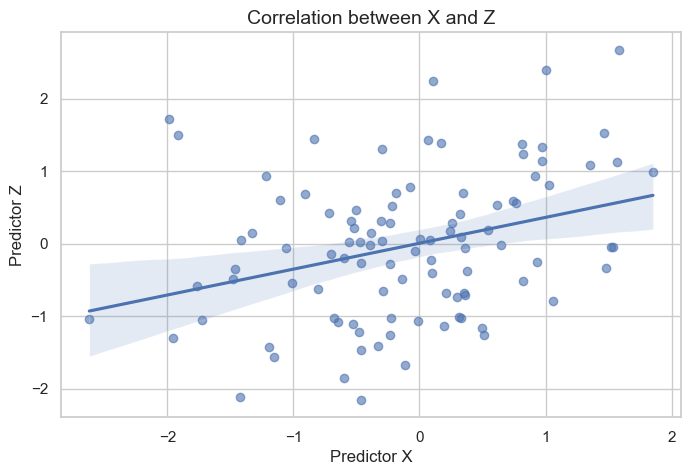

Full Model Results
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     1373.
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           7.11e-72
Time:                        23:52:20   Log-Likelihood:                -147.62
No. Observations:                 100   AIC:                             301.2
Df Residuals:                      97   BIC:                             309.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0886      0.108 

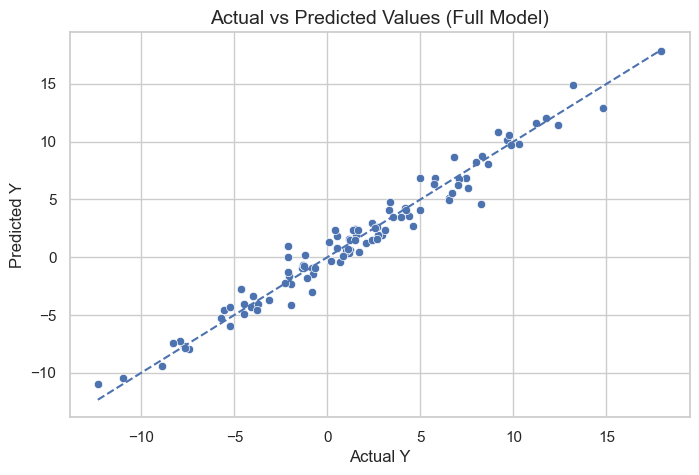


Omitted Model Results
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.538
Model:                            OLS   Adj. R-squared:                  0.534
Method:                 Least Squares   F-statistic:                     114.3
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           3.88e-18
Time:                        23:52:22   Log-Likelihood:                -277.87
No. Observations:                 100   AIC:                             559.7
Df Residuals:                      98   BIC:                             564.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1183      0.

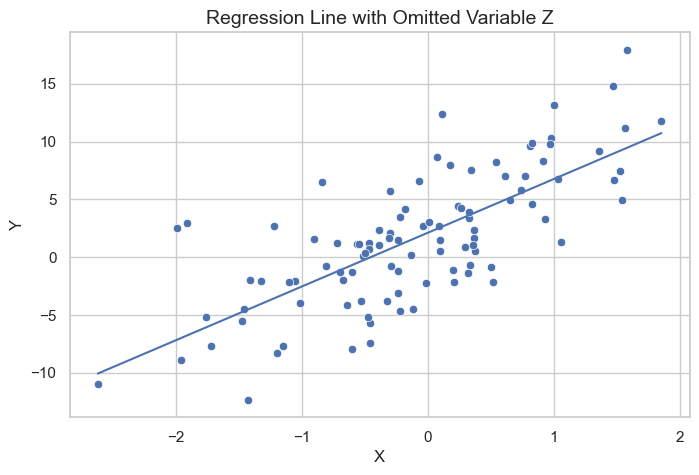

C:\Users\DELL\AppData\Local\Temp\ipykernel_6928\1626885507.py:97: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b_full.append(full.params[1])
C:\Users\DELL\AppData\Local\Temp\ipykernel_6928\1626885507.py:97: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b_full.append(full.params[1])
C:\Users\DELL\AppData\Local\Temp\ipykernel_6928\1626885507.py:97: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b_full.append(full.params[1])
C:\Users\D

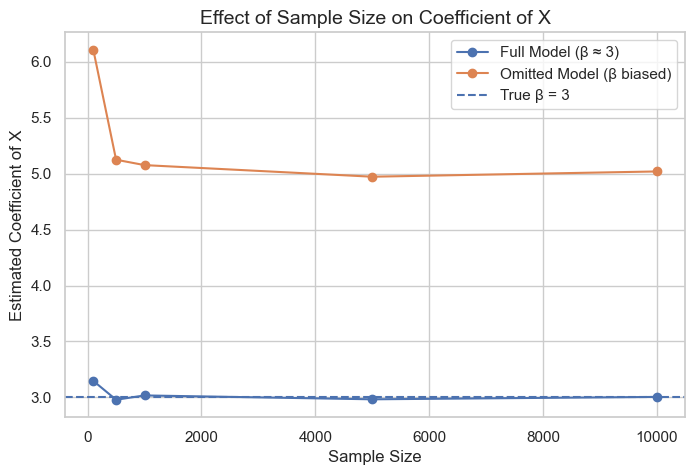

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

np.random.seed(42)

# -----------------------------
# Step 1: Simulate Data
# -----------------------------
n = 100

X = np.random.normal(0,1,n)
Z = 0.5*X + np.random.normal(0,1,n)
e = np.random.normal(0,1,n)

Y = 2 + 3*X + 4*Z + e

data = pd.DataFrame({"Y":Y,"X":X,"Z":Z})

# -----------------------------
# Plot 1: Correlation between X and Z
# -----------------------------
plt.figure()
sns.regplot(x=X, y=Z, scatter_kws={"alpha":0.6})
plt.title("Correlation between X and Z", fontsize=14)
plt.xlabel("Predictor X")
plt.ylabel("Predictor Z")
plt.show()

# -----------------------------
# Step 2: Full Model
# -----------------------------
X_full = sm.add_constant(data[["X","Z"]])
model_full = sm.OLS(Y, X_full).fit()

print("Full Model Results")
print(model_full.summary())

# Predicted values
Y_pred_full = model_full.predict(X_full)

# Plot 2: Actual vs Predicted
plt.figure()
sns.scatterplot(x=Y, y=Y_pred_full)
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], linestyle='--')
plt.title("Actual vs Predicted Values (Full Model)", fontsize=14)
plt.xlabel("Actual Y")
plt.ylabel("Predicted Y")
plt.show()

# -----------------------------
# Step 3: Omitted Model
# -----------------------------
X_omit = sm.add_constant(data["X"])
model_omit = sm.OLS(Y, X_omit).fit()

print("\nOmitted Model Results")
print(model_omit.summary())

# Plot 3: Regression with Only X
plt.figure()
sns.scatterplot(x=X, y=Y)
sns.lineplot(x=X, y=model_omit.predict(X_omit))
plt.title("Regression Line with Omitted Variable Z", fontsize=14)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

# -----------------------------
# Step 4: Sample Size Experiment
# -----------------------------
sizes = [100, 500, 1000, 5000, 10000]

b_full = []
b_omit = []

for n in sizes:
    
    X = np.random.normal(0,1,n)
    Z = 0.5*X + np.random.normal(0,1,n)
    e = np.random.normal(0,1,n)
    
    Y = 2 + 3*X + 4*Z + e
    
    Xf = sm.add_constant(pd.DataFrame({"X":X,"Z":Z}))
    Xm = sm.add_constant(X)
    
    full = sm.OLS(Y, Xf).fit()
    omit = sm.OLS(Y, Xm).fit()
    
    b_full.append(full.params[1])
    b_omit.append(omit.params[1])

# Plot 4: Sample Size vs Coefficient
plt.figure()
plt.plot(sizes, b_full, marker='o', label="Full Model (β ≈ 3)")
plt.plot(sizes, b_omit, marker='o', label="Omitted Model (β biased)")
plt.axhline(3, linestyle="--", label="True β = 3")

plt.title("Effect of Sample Size on Coefficient of X", fontsize=14)
plt.xlabel("Sample Size")
plt.ylabel("Estimated Coefficient of X")
plt.legend()
plt.show()